[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/matibilkis/RL-UBA-2026/blob/main/clase_4/gridworld_minimal.ipynb)

# Gridworld mínimo

Clase 4. Grilla $N\times N$, sin obstáculos internos (las paredes son los límites de la grilla). Arranca el modelo (`p(s'|s,a)` expuesto a mano) — policy evaluation / improvement / iteration / value iteration van en el próximo notebook.

In [1]:
%pip install -q gymnasium  # no viene preinstalado en Colab; numpy/matplotlib/IPython sí

/home/mbilkis/.cache/uv/builds-v0/.tmpLNWnHV/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np

## Acciones

In [3]:
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
ACTIONS = [UP, DOWN, LEFT, RIGHT]
ACTION_SYMBOL = {UP: "↑", DOWN: "↓", LEFT: "←", RIGHT: "→"}
ACTION_DELTA = {UP: (-1, 0), DOWN: (1, 0), LEFT: (0, -1), RIGHT: (0, 1)}

REWARD_STEP = -1.0  # se cobra en todo movimiento, incluso al chocar contra la pared

## El entorno

Estados = casilleros de la grilla, numerados `0..N*N-1` 

 Inicial = arriba-izquierda, terminal = abajo-izquierda. Las paredes son los bordes de la grilla: si una acción te saca del grid, te quedás en el mismo casillero (y igual cobrás el `REWARD_STEP`).


`P[s][a]` guarda `(prob, s', reward, done)` ... es a propósito ese formato xq `env.unwrapped.P` de Gymnasium,una sola tupla por par `(s,a)`).

In [4]:
class GridWorld:
    def __init__(self, N):
        self.N = N
        self.n_states = N * N
        self.start_state = self._to_id(0, 0)
        self.terminal_state = self._to_id(N - 1, 0)
        self.P = self._build_transitions()

    def _to_id(self, row, col):
        return row * self.N + col

    def _to_rc(self, s): #to_row_columns
        return divmod(s, self.N) # ej divmod(21,5) = 4,1

    def _build_transitions(self):
        # tiro (prob, s' , reward, done)
        P = {s: {a: None for a in ACTIONS} for s in range(self.n_states)}
        for s in range(self.n_states):
            row, col = self._to_rc(s)
            for a in ACTIONS:
                if s == self.terminal_state:
                    P[s][a] = (1.0, s, 0.0, True)  # absorbente: v(terminal) = 0
                    continue
                dr, dc = ACTION_DELTA[a]
                new_row, new_col = row + dr, col + dc
                if 0 <= new_row < self.N and 0 <= new_col < self.N:
                    s_next = self._to_id(new_row, new_col)
                else:
                    s_next = s  # chocaste contra la pared, no te movés
                done = s_next == self.terminal_state
                P[s][a] = (1.0, s_next, REWARD_STEP, done)
        return P

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        _, s_next, reward, done = self.P[self.state][action]
        self.state = s_next
        return s_next, reward, done

## Policy

Por ahora, la única que necesitamos: uniforme al azar. `pi[s, a]` = $\pi(a|s)$, matriz `n_states x n_actions`.

In [5]:
def uniform_random_policy(env):
    pi = np.ones((env.n_states, len(ACTIONS))) / len(ACTIONS)
    return pi

## Chequeo rápido

Grilla $4\times4$ (S = inicial, T = terminal), y unos pasos a mano: subir desde el inicio te tiene que chocar contra la pared (mismo estado, reward -1); bajar tres veces te tiene que llevar al terminal.

In [6]:
N = 4
env = GridWorld(N)
pi = uniform_random_policy(env)


def print_grid(env):
    for row in range(env.N):
        cells = []
        for col in range(env.N):
            s = env._to_id(row, col)
            if s == env.start_state:
                cells.append("S")
            elif s == env.terminal_state:
                cells.append("T")
            else:
                cells.append(".")
        print(" ".join(cells))


print_grid(env)
print("n_states:", env.n_states, "| pi shape:", pi.shape)

s = env.reset()
s, r, done = env.step(UP)
print(f"\nUP desde el inicio -> estado {s} (esperado {env.start_state}), reward {r}, done {done}")

env.reset()
for _ in range(N - 1):
    s, r, done = env.step(DOWN)
print(f"DOWN x{N-1} desde el inicio -> estado {s} (esperado {env.terminal_state}), reward {r}, done {done}")

S . . .
. . . .
. . . .
T . . .
n_states: 16 | pi shape: (16, 4)

UP desde el inicio -> estado 0 (esperado 0), reward -1.0, done False
DOWN x3 desde el inicio -> estado 12 (esperado 12), reward -1.0, done True


## Visualizar: el Gólem caminando por la grilla

Un `render` mínimo (matplotlib, nada de HTML/JS) + un loop que lo anima re-dibujando el frame (`clear_output`), pensado para correr interactivo en el notebook.

In [7]:
# PNG del Gólem embebido en base64 -- así el notebook no depende de ningún
# archivo externo (necesario para que corra en Colab con "Run all" sin subir nada a mano)
GOLEM_PNG_B64 = "..."

In [8]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from IPython.display import display, clear_output
import time

import base64
from io import BytesIO

GOLEM_IMG = plt.imread(BytesIO(base64.b64decode(GOLEM_PNG_B64)), format="png")


def render(env, state, ax=None, trajectory=None):
    row, col = env._to_rc(state)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.clear()
    ax.set_xlim(0, env.N)
    ax.set_ylim(0, env.N)
    ax.set_xticks(range(env.N + 1))
    ax.set_yticks(range(env.N + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True)
    ax.invert_yaxis()  # fila 0 arriba, como en print_grid

    t_row, t_col = env._to_rc(env.terminal_state)
    ax.add_patch(plt.Rectangle((t_col, t_row), 1, 1, color="lightgreen", zorder=0))

    if trajectory:  # el trazo de ESTA corrida en particular
        rc = [env._to_rc(s) for s in trajectory]
        xs = [c + 0.5 for _, c in rc]
        ys = [r + 0.5 for r, _ in rc]
        ax.plot(xs, ys, "-o", color="royalblue", markersize=4, linewidth=2, alpha=0.6, zorder=1)

    ax.add_artist(AnnotationBbox(OffsetImage(GOLEM_IMG, zoom=0.15), (col + 0.5, row + 0.5), frameon=False, zorder=2))
    return ax

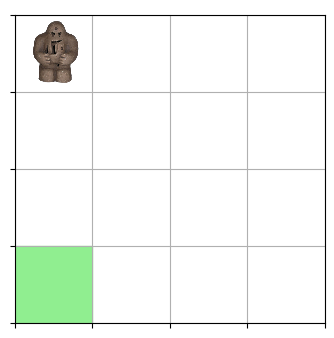

In [9]:
render(env, env.start_state)
plt.show()

In [10]:
def animate_episode(env, pi, max_steps=30, pause=0.15):
    s = env.reset()
    trajectory = [s]
    fig, ax = plt.subplots(figsize=(4, 4))
    for _ in range(max_steps):
        render(env, s, ax, trajectory)
        clear_output(wait=True)
        display(fig)
        time.sleep(pause)
        if s == env.terminal_state:
            break
        a = np.random.choice(ACTIONS, p=pi[s])
        s, _, _ = env.step(a)
        trajectory.append(s)
    plt.close(fig)
    return trajectory

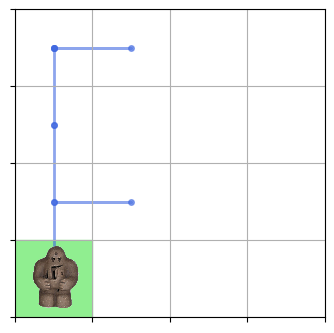

[0, 1, 0, 0, 0, 4, 4, 8, 9, 8, 12]

In [11]:
animate_episode(env, pi, max_steps=30)  # con la policy uniforme al azar, camina medio perdido

## Policy evaluation

Barrido iterativo sobre `P`, hasta el punto fijo de $T^\pi$: $V(s) \leftarrow \sum_a \pi(a|s)\,[r + \gamma V(s')]$.

In [12]:
def policy_evaluation(env, pi, gamma=1.0, theta=1e-6):
    V = np.zeros(env.n_states)
    while True:
        delta = 0.0
        for s in range(env.n_states):
            v_old = V[s]
            v_new = 0.0
            for a in ACTIONS:
                _, s_next, reward, _ = env.P[s][a]
                v_new += pi[s, a] * (reward + gamma * V[s_next])
            V[s] = v_new
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            break
    return V

In [13]:
V_random = policy_evaluation(env, pi)  # bajo la policy uniforme al azar
print("V bajo la policy uniforme al azar:")
print(V_random.reshape(env.N, env.N))

V bajo la policy uniforme al azar:
[[-51.71425865 -54.28568632 -57.42854201 -59.42854102]
 [-45.14283437 -49.71426098 -54.57140149 -57.42854293]
 [-29.9999855  -40.85712324 -49.71426176 -54.28568805]
 [  0.         -29.99998596 -45.14283578 -51.71426112]]


## Policy improvement

Greedy respecto a $V$: $\pi'(s) = \arg\max_a [r + \gamma V(s')]$ (empates se reparten uniforme entre las mejores acciones).

In [14]:
def policy_improvement(env, V, gamma=1.0):
    pi_new = np.zeros((env.n_states, len(ACTIONS)))
    for s in range(env.n_states):
        q = np.array([env.P[s][a][2] + gamma * V[env.P[s][a][1]] for a in ACTIONS])
        best = np.flatnonzero(np.isclose(q, q.max()))
        pi_new[s, best] = 1.0 / len(best)
    return pi_new

In [15]:
def print_policy_grid(env, pi):
    for row in range(env.N):
        cells = []
        for col in range(env.N):
            s = env._to_id(row, col)
            cells.append("T" if s == env.terminal_state else ACTION_SYMBOL[np.argmax(pi[s])])
        print(" ".join(cells))


pi_improved = policy_improvement(env, V_random)  # una sola pasada de mejora sobre V_random
print_policy_grid(env, pi_improved)
# en ESTE laberinto (sin obstáculos) una sola mejora ya da la óptima —
# no es lo general, por eso policy_iteration de abajo repite el ciclo hasta que no cambie más

↓ ↓ ← ↓
↓ ↓ ↓ ↓
↓ ↓ ← ←
T ← ← ←


## Convergencia sweep a sweep

$v_k$ de la policy uniforme al azar, sweep a sweep, y al lado la policy greedy que resultaría de frenar la evaluación justo ahí — mismo formato que la figura de S&B (ojo: nuestro laberinto tiene un solo estado terminal, no dos como el de ellos, así que los números no son los mismos — la idea sí).

In [16]:
def policy_evaluation_history(env, pi, gamma=1.0, theta=1e-6):
    """Igual idea que policy_evaluation, pero con sweep sincrónico (todos los
    estados se actualizan a partir del V del sweep anterior, no in-place) y
    guardando una foto de V después de cada sweep — para poder graficar la
    convergencia paso a paso, como la fig. 4.1 de Sutton & Barto."""
    V = np.zeros(env.n_states)
    history = [V.copy()]
    while True:
        V_new = np.zeros(env.n_states)
        for s in range(env.n_states):
            for a in ACTIONS:
                _, s_next, reward, _ = env.P[s][a]
                V_new[s] += pi[s, a] * (reward + gamma * V[s_next])
        delta = np.max(np.abs(V_new - V))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            break
    return history

In [17]:
def plot_value_and_policy_progress(env, history, checkpoints, gamma=1.0):
    """checkpoints: lista de sweeps k a mostrar (None = el último, ya convergido)."""
    fig, axes = plt.subplots(len(checkpoints), 2, figsize=(4.6, 2.1 * len(checkpoints)))
    for row, k in enumerate(checkpoints):
        idx = (len(history) - 1) if k is None else min(k, len(history) - 1)
        V_k = history[idx]
        pi_k = policy_improvement(env, V_k, gamma)
        for col, kind in enumerate(["value", "policy"]):
            ax = axes[row, col]
            ax.set_xlim(0, env.N)
            ax.set_ylim(0, env.N)
            ax.set_xticks(range(env.N + 1))
            ax.set_yticks(range(env.N + 1))
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.grid(True, color="black", linewidth=0.5)
            ax.invert_yaxis()
            for s in range(env.n_states):
                r, c = env._to_rc(s)
                if kind == "value":
                    text = f"{V_k[s]:.1f}"
                else:
                    text = "T" if s == env.terminal_state else ACTION_SYMBOL[np.argmax(pi_k[s])]
                ax.text(c + 0.5, r + 0.5, text, ha="center", va="center", fontsize=9)
            if row == 0:
                ax.set_title("$v_k$" if kind == "value" else "greedy($v_k$)", fontsize=11)
        label_k = "∞" if k is None else str(k)
        axes[row, 0].set_ylabel(f"k = {label_k}", fontsize=11, rotation=0, labelpad=28, va="center")
    fig.tight_layout()
    return fig

sweeps hasta converger: 701


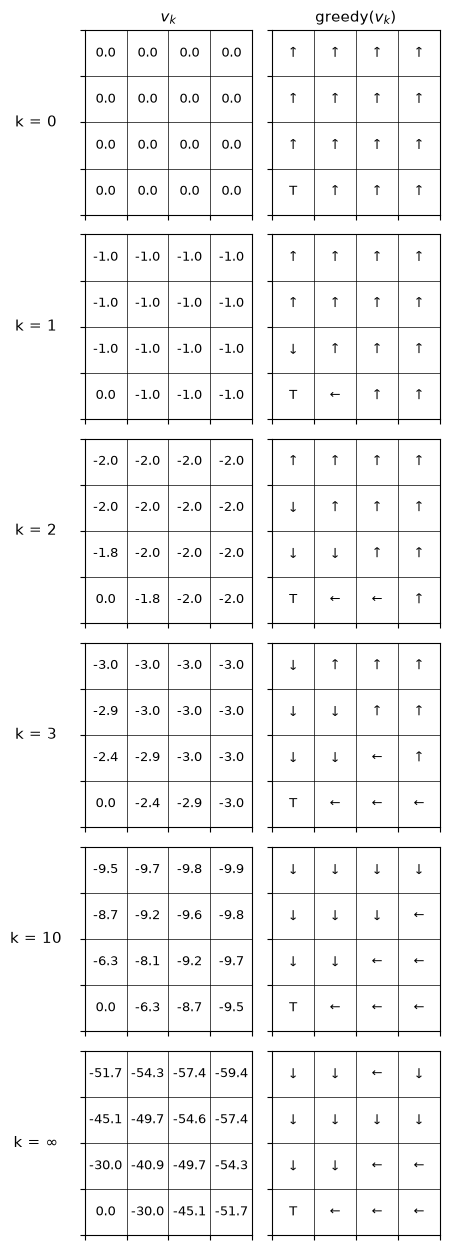

In [18]:
history_random = policy_evaluation_history(env, pi)
print("sweeps hasta converger:", len(history_random) - 1)
plot_value_and_policy_progress(env, history_random, checkpoints=[0, 1, 2, 3, 10, None])
plt.show()

## Policy iteration

Alternar evaluación completa + mejora, hasta que la policy no cambie más.

In [19]:
def policy_iteration(env, gamma=1.0, theta=1e-6):
    pi = uniform_random_policy(env)
    while True:
        V = policy_evaluation(env, pi, gamma, theta)
        pi_new = policy_improvement(env, V, gamma)
        if np.allclose(pi_new, pi):
            break
        pi = pi_new
    return pi, V

In [20]:
pi_star_pit, V_star_pit = policy_iteration(env)
print("V* (policy iteration):")
print(V_star_pit.reshape(env.N, env.N))
print()
print_policy_grid(env, pi_star_pit)

V* (policy iteration):
[[-3. -4. -5. -6.]
 [-2. -3. -4. -5.]
 [-1. -2. -3. -4.]
 [ 0. -1. -2. -3.]]

↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
T ← ← ←


## Value iteration

Un solo sweep de evaluación (sin converger) + mejora en cada paso, en un solo operador — aplicar directo el Bellman óptimo $T^*$: $V(s) \leftarrow \max_a [r + \gamma V(s')]$.

In [21]:
def value_iteration(env, gamma=1.0, theta=1e-6):
    V = np.zeros(env.n_states)
    while True:
        delta = 0.0
        for s in range(env.n_states):
            v_old = V[s]
            q = [env.P[s][a][2] + gamma * V[env.P[s][a][1]] for a in ACTIONS]
            V[s] = max(q)
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            break
    pi = policy_improvement(env, V, gamma)  # extraer la policy greedy final
    return pi, V

In [22]:
pi_star_vi, V_star_vi = value_iteration(env)
print("V* (value iteration):")
print(V_star_vi.reshape(env.N, env.N))
print()
print_policy_grid(env, pi_star_vi)

V* (value iteration):
[[-3. -4. -5. -6.]
 [-2. -3. -4. -5.]
 [-1. -2. -3. -4.]
 [ 0. -1. -2. -3.]]

↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
T ← ← ←


## Chequeo final

Sin obstáculos internos, el camino óptimo al terminal es la distancia Manhattan — se puede verificar $V_*$ a mano: $V_*(s) = -\big((N-1-\text{fila}) + \text{columna}\big)$.

In [23]:
rows, cols = np.divmod(np.arange(env.n_states), env.N)
V_closed_form = -((env.N - 1 - rows) + cols).astype(float)

print("policy iteration == value iteration:", np.allclose(V_star_pit, V_star_vi))
print("value iteration == fórmula cerrada (distancia Manhattan):", np.allclose(V_star_vi, V_closed_form, atol=1e-3))

policy iteration == value iteration: True
value iteration == fórmula cerrada (distancia Manhattan): True


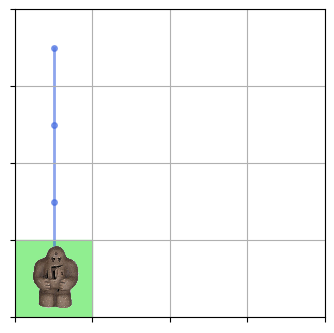

[0, 4, 8, 12]

In [24]:
animate_episode(env, pi_star_vi, max_steps=2 * env.N)  # ahora el Gólem ya no camina perdido

## Migración a `gymnasium.Env`


In [25]:
import gymnasium as gym
from gymnasium import spaces


class GymGridWorld(gym.Env):
    def __init__(self, N):
        super().__init__()
        self._core = GridWorld(N)  # el modelo (P) no cambia
        self.observation_space = spaces.Discrete(self._core.n_states)
        self.action_space = spaces.Discrete(len(ACTIONS))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs = self._core.reset()
        return obs, {}

    def step(self, action):
        obs, reward, terminated = self._core.step(action)
        truncated = False  # no hay time-limit artificial en este laberinto
        return obs, reward, terminated, truncated, {}

## Chequeo — mismo comportamiento, interfaz nueva

Mismos dos casos de antes (chocar la pared, llegar al terminal), pero ahora vía `step`/`reset` de Gymnasium.

In [26]:
gym_env = GymGridWorld(N)
print("observation_space:", gym_env.observation_space)
print("action_space:     ", gym_env.action_space)

obs, info = gym_env.reset()
obs, reward, terminated, truncated, info = gym_env.step(UP)
print(f"\nUP desde el inicio -> obs {obs}, reward {reward}, terminated {terminated}, truncated {truncated}")

gym_env.reset()
for _ in range(N - 1):
    obs, reward, terminated, truncated, info = gym_env.step(DOWN)
print(f"DOWN x{N-1}          -> obs {obs}, reward {reward}, terminated {terminated}, truncated {truncated}")

observation_space: Discrete(16)
action_space:      Discrete(4)

UP desde el inicio -> obs 0, reward -1.0, terminated False, truncated False
DOWN x3          -> obs 12, reward -1.0, terminated True, truncated False


## Bonus: `gym.make()`

Con `register`, se puede instanciar por nombre — `gym.make` además envuelve el env en los chequeos estándar de Gymnasium (`PassiveEnvChecker`, `OrderEnforcing`), así que si esto corre sin errores, `GymGridWorld` cumple el contrato completo de `gymnasium.Env`.

In [27]:
from gymnasium.envs.registration import register

register(id="Gridworld-v0", entry_point=lambda: GymGridWorld(N))
made_env = gym.make("Gridworld-v0")

obs, info = made_env.reset()
obs, reward, terminated, truncated, info = made_env.step(DOWN)
print(made_env)
print("step DOWN:", obs, reward, terminated, truncated, info)

<OrderEnforcing<PassiveEnvChecker<GymGridWorld<Gridworld-v0>>>>
step DOWN: 4 -1.0 False False {}
